In [1]:
from __future__ import annotations

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [2]:
# Load all matches features
all_matches_features = pd.read_csv("/Users/mariusschonberg/Desktop/Speciale/outputs/outputs/all_matches_features_final.csv")
print(f"Skud i alt: {len(all_matches_features)}")


Skud i alt: 4957


In [3]:
# Utils.py
sys.path.insert(0, "/Users/mariusschonberg/Desktop/Speciale/code/models")
from Utils import (
    FEATURES,
    _encode_features,
    _impute_with_train_median,
    _pooled_auc,
    _pooled_ll,
)


In [4]:
import inspect
print(inspect.getsource(_encode_features))

def _encode_features(df_sub: pd.DataFrame) -> np.ndarray:
    """Label-encod kategoriske kolonner og konvertér til numpy array."""
    X = df_sub.copy()
    for col in X.columns:
        if X[col].dtype == object or str(X[col].dtype) == "category":
            codes, _ = pd.factorize(X[col])
            X[col] = codes.astype(float)
            X.loc[X[col] == -1, col] = np.nan
        else:
            X[col] = pd.to_numeric(X[col], errors="coerce")
    return X.to_numpy(dtype=float)



In [5]:
# Encode kategoriske variable og gem feature-navne
feature_names = all_matches_features[FEATURES].columns.tolist()
X = _encode_features(all_matches_features[FEATURES])
y = all_matches_features["is_goal"].astype(int).to_numpy()

In [6]:
# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {len(X_train)} skud  |  Test: {len(X_test)} skud")


Train: 3965 skud  |  Test: 992 skud


In [7]:
# Imputer NaN og standardiser
X_train, X_test = _impute_with_train_median(X_train, X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [8]:
# Træn Logistic Regression
model = LogisticRegression(max_iter=1000, C=1.0, class_weight="balanced")
model.fit(X_train_scaled, y_train)
print("Model fitted")


Model fitted


In [9]:
# Koefficienter
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", ascending=False)

print(coef_df)


                    feature  coefficient
1                 angle_rad     1.080308
14        shooter_speed_mps     0.927404
0                distance_m     0.621523
6        pressure_nd_dist_m     0.598522
4            shot_body_part     0.195878
13           ball_speed_mps     0.141696
5              play_pattern     0.083959
2                 goal_diff     0.049215
3   time_since_last_event_s    -0.048862
12        gk_lateral_offset    -0.085482
9         obstruction_count    -0.188091
11                 gk_depth    -0.198138
8    pressure_def_count_r2m    -0.210472
7    pressure_def_count_r1m    -0.306337
10         gk_ball_distance    -0.704171


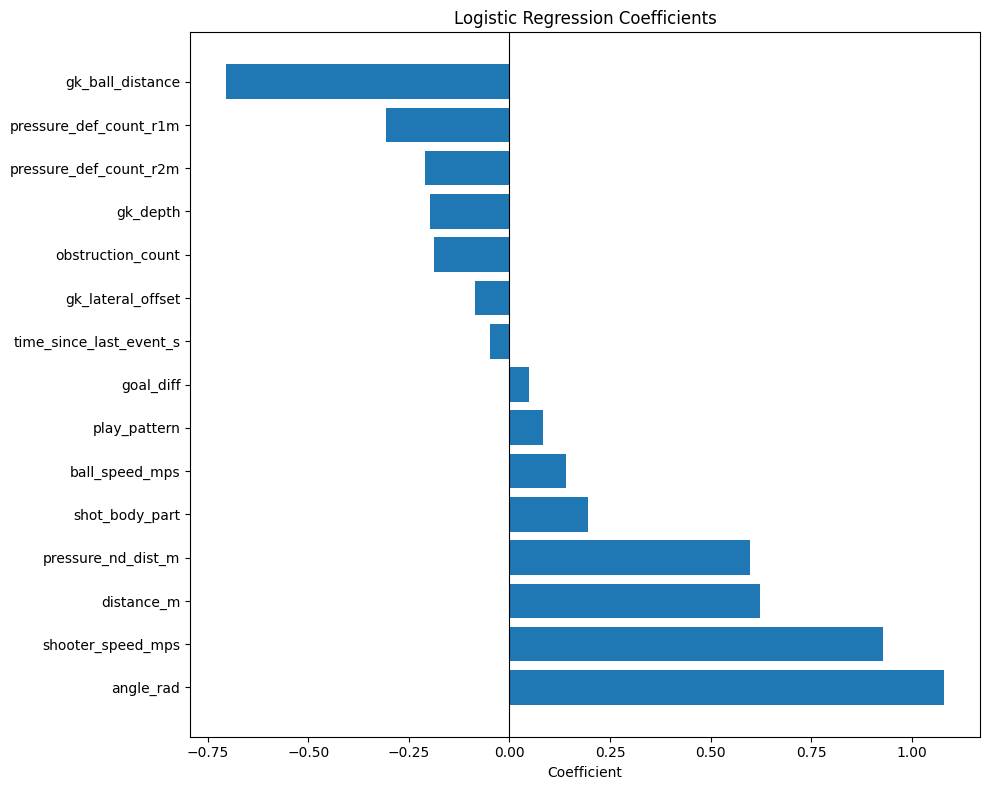

In [10]:
# Barplot af koefficienter
plt.figure(figsize=(10, 8))
plt.barh(coef_df["feature"], coef_df["coefficient"])
plt.axvline(x=0, color="black", linewidth=0.8)
plt.xlabel("Coefficient")
plt.title("Logistic Regression Coefficients")
plt.tight_layout()
plt.savefig("/Users/mariusschonberg/Desktop/Speciale/thesis/figures/logreg_coefficients.png", dpi=150)
plt.show()

In [11]:
import pandas as pd
df = pd.read_csv("/Users/mariusschonberg/Desktop/Speciale/outputs/outputs/all_matches_features_final.csv")

In [12]:
print(df[["gk_ball_distance"]].describe())
print(df[df["is_goal"]==1]["gk_ball_distance"].mean())
print(df[df["is_goal"]==0]["gk_ball_distance"].mean())

       gk_ball_distance
count       4957.000000
mean          13.804366
std            6.872386
min            0.044721
25%            8.484486
50%           13.103759
75%           18.636000
max           49.286739
10.523214365574619
14.247663745214284
